In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

df = pd.read_csv("data.csv")
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (11914, 16)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
## data set overview

df.info()

df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [4]:
## missing values check
missing_values = df.isnull().sum()
print(missing_values)


Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64


In [5]:
## Remove Duplicate Records
# Remove duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (11199, 16)


In [6]:
## Handle Missing Value

df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].median())


df['Number of Doors'] = df['Number of Doors'].fillna(df['Number of Doors'].mode()[0])

df = df.dropna(subset=['MSRP'])


In [7]:
## Feature Engineering (Year → Car Age)
current_year = 2025

df['Car Age'] = current_year - df['Year']

# Drop original Year column
df.drop('Year', axis=1, inplace=True)


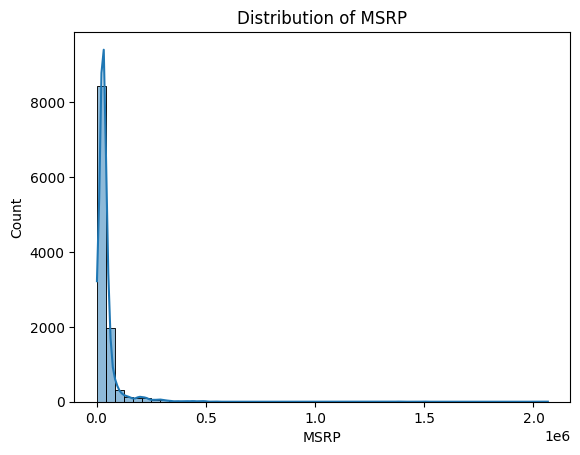

In [8]:
## EDA
# msp distribution
plt.figure()
sns.histplot(df['MSRP'], bins=50, kde=True)
plt.title("Distribution of MSRP")
plt.show()


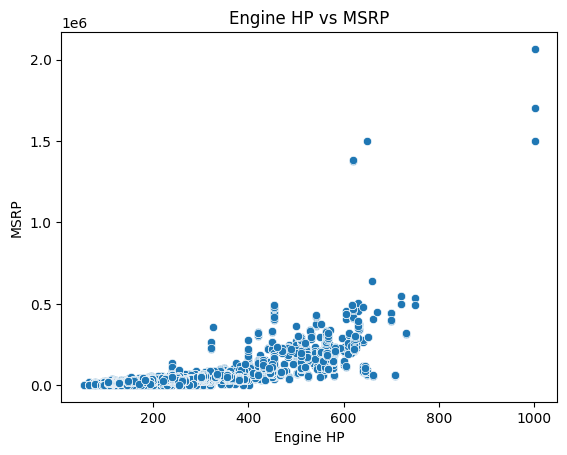

In [9]:
## Engine HP vs MSRP
plt.figure()
sns.scatterplot(x='Engine HP', y='MSRP', data=df)
plt.title("Engine HP vs MSRP")
plt.show()


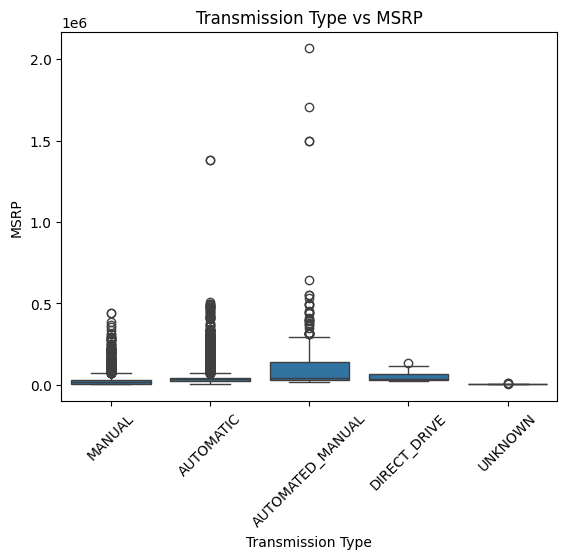

In [10]:
## Transmission Type vs MSRP
plt.figure()
sns.boxplot(x='Transmission Type', y='MSRP', data=df)
plt.xticks(rotation=45)
plt.title("Transmission Type vs MSRP")
plt.show()

In [11]:
## Encoding Categorical Variables

df_encoded = pd.get_dummies(df, drop_first=True)

print("Shape after encoding:", df_encoded.shape)


Shape after encoding: (11199, 1072)


In [ ]:
## conculsion
##  data set is fully and successfully cleaned by removing null values and removing duplicates and performing feature engeering